In [1]:
import pandas as pd
df=pd.read_csv("zomato.csv")
print(df.columns.tolist())
print(df.shape)
df

['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']
(51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [2]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [3]:
import re

def get_avg_rating(review):
    ratings = re.findall(r'Rated (\d\.\d)', str(review))
    ratings = [float(r) for r in ratings]
    if len(ratings) > 0:
        return sum(ratings) / len(ratings)
    else:
        return None

sample = df[df['rate'].isnull()][['reviews_list']].head(5).copy()

sample['extracted_rating'] = sample['reviews_list'].apply(get_avg_rating)

print(sample)

                                          reviews_list  extracted_rating
84   [('Rated 4.0', 'RATED\n  Good Location. Small ...               4.0
90   [('Rated 1.0', 'RATED\n  Do not order anything...               1.0
91                                                  []               NaN
92                                                  []               NaN
107                                                 []               NaN


In [4]:

df['rate'] = df.apply(
    lambda row: get_avg_rating(row['reviews_list']) if pd.isnull(row['rate']) else row['rate'],
    axis=1
)

In [5]:
d1=df.copy()
d1=df.dropna(subset=['rate'])
print(d1.shape)
d1.isnull().sum()

(46443, 17)


url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                            985
location                           0
rest_type                        160
dish_liked                     22807
cuisines                          17
approx_cost(for two people)      301
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [6]:

sample_before = d1[['cuisines']].head(5).copy()

d2 = d1.copy()
d2['cuisines'] = d2['cuisines'].str.split(',').str[0]
d2['cuisines'] = d2['cuisines'].fillna(d2['cuisines'].mode()[0])

sample_after = d2[['cuisines']].head(5)

comparison = pd.DataFrame({
    'Before': sample_before['cuisines'],
    'After': sample_after['cuisines']
})

print(comparison)

                           Before         After
0  North Indian, Mughlai, Chinese  North Indian
1     Chinese, North Indian, Thai       Chinese
2          Cafe, Mexican, Italian          Cafe
3      South Indian, North Indian  South Indian
4        North Indian, Rajasthani  North Indian


In [7]:

d3 = d2.copy()

d3['approx_cost(for two people)'] = d3['approx_cost(for two people)'].str.replace(',', '')


d3['approx_cost(for two people)'] = pd.to_numeric(
    d3['approx_cost(for two people)'], errors='coerce'
)

median_value = d3['approx_cost(for two people)'].median()

d3['approx_cost(for two people)'] = d3['approx_cost(for two people)'].fillna(median_value)
print("\nMedian Value Used:", median_value)
print(d3.isnull().sum())


Median Value Used: 450.0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                            985
location                           0
rest_type                        160
dish_liked                     22807
cuisines                           0
approx_cost(for two people)        0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [8]:
d3['rest_type'] = d3['rest_type'].str.split(',').str[0]
mode_value = d3['rest_type'].mode()[0]
d3['rest_type']=d3['rest_type'].fillna(mode_value)
print("Mode Value Used:", mode_value)
print(d3.isnull().sum())

Mode Value Used: Quick Bites
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                            985
location                           0
rest_type                          0
dish_liked                     22807
cuisines                           0
approx_cost(for two people)        0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [9]:

cols_to_drop = ['phone', 'menu_item', 'url', 'address', 'dish_liked']

d3.drop(columns=cols_to_drop, inplace=True)

print(d3.columns)

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)', 'reviews_list',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


In [10]:
print(d3.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
listed_in(type)                0
listed_in(city)                0
dtype: int64


In [11]:
d3['rate'] = d3['rate'].str.replace('/5', '')
d3['rate'] = pd.to_numeric(d3['rate'], errors='coerce')
d3['approx_cost(for two people)'] = d3['approx_cost(for two people)'].astype(str).str.replace(',', '')
d3['approx_cost(for two people)'] = pd.to_numeric(d3['approx_cost(for two people)'], errors='coerce')


In [12]:
d3_clean = d3.copy()

cols = ['votes', 'approx_cost(for two people)','rate']

for col in cols:
    total_rows = len(d3_clean)

    Q1 = d3_clean[col].quantile(0.25)
    Q3 = d3_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = d3_clean[(d3_clean[col] < lower) | (d3_clean[col] > upper)]
    count = len(outliers)
    percentage = (count / total_rows) * 100

    print(f"\n{col}: {count} outliers ({percentage:.2f}%)")

    if percentage < 5:
        print("→ Removing outliers")
        d3_clean = d3_clean[(d3_clean[col] >= lower) & (d3_clean[col] <= upper)]
    else:
        print("→ Capping outliers")
        d3_clean[col] = d3_clean[col].clip(lower, upper)


votes: 6164 outliers (13.27%)
→ Capping outliers

approx_cost(for two people): 3228 outliers (6.95%)
→ Capping outliers

rate: 187 outliers (0.40%)
→ Removing outliers


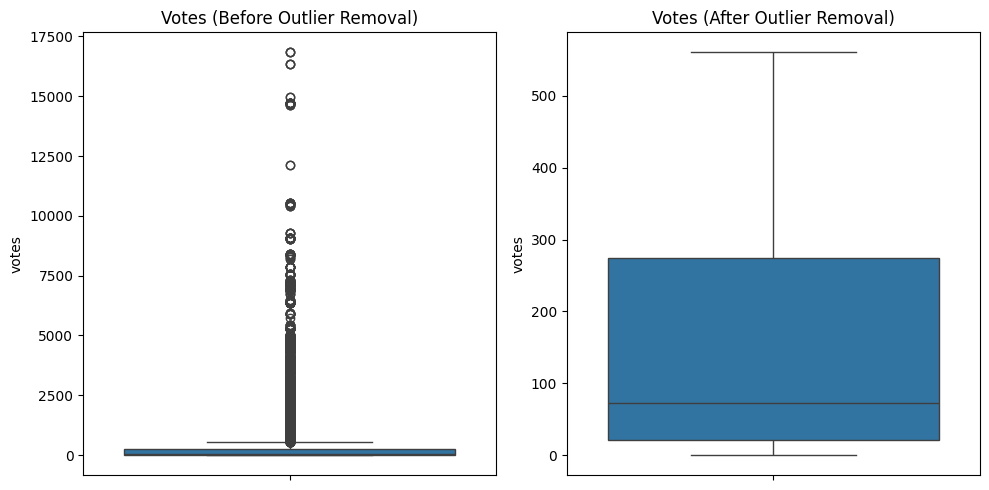

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=d3['votes'])
plt.title("Votes (Before Outlier Removal)")

plt.subplot(1,2,2)
sns.boxplot(y=d3_clean['votes'])
plt.title("Votes (After Outlier Removal)")

plt.tight_layout()
plt.show()

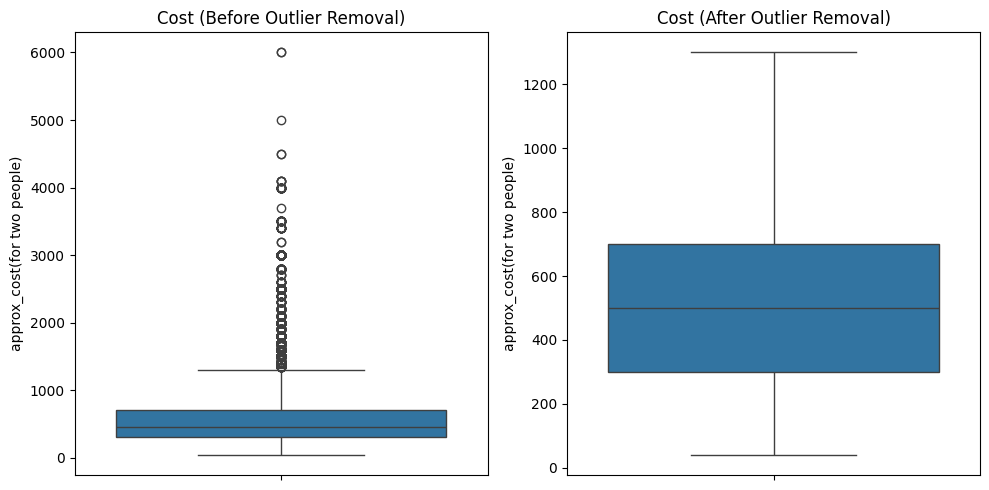

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=d3['approx_cost(for two people)'])
plt.title("Cost (Before Outlier Removal)")

plt.subplot(1,2,2)
sns.boxplot(y=d3_clean['approx_cost(for two people)'])
plt.title("Cost (After Outlier Removal)")

plt.tight_layout()
plt.show()

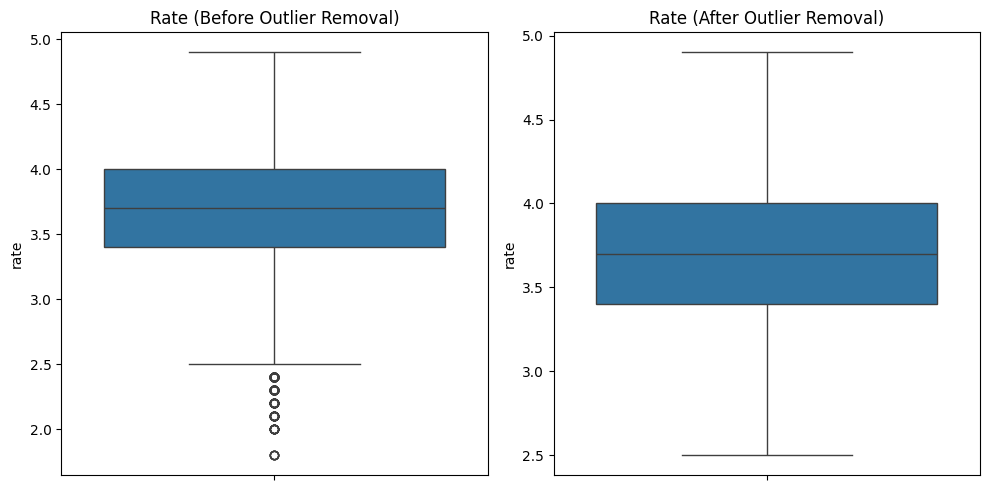

In [15]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=d3['rate'])
plt.title("Rate (Before Outlier Removal)")

plt.subplot(1,2,2)
sns.boxplot(y=d3_clean['rate'])
plt.title("Rate (After Outlier Removal)")

plt.tight_layout()
plt.show()

In [16]:
d3[['votes', 'approx_cost(for two people)', 'rate']].skew()

votes                          7.196609
approx_cost(for two people)    2.515202
rate                          -0.328601
dtype: float64

In [17]:
d3[['votes', 'approx_cost(for two people)', 'rate']].kurt()

votes                          80.771175
approx_cost(for two people)     9.758967
rate                           -0.007483
dtype: float64

In [20]:
d3_clean[['votes', 'approx_cost(for two people)', 'rate']].skew()

votes                          1.053185
approx_cost(for two people)    0.948716
rate                          -0.226547
dtype: float64

In [21]:
d3_clean[['votes', 'approx_cost(for two people)', 'rate']].kurt()

votes                         -0.467023
approx_cost(for two people)   -0.095127
rate                          -0.289465
dtype: float64

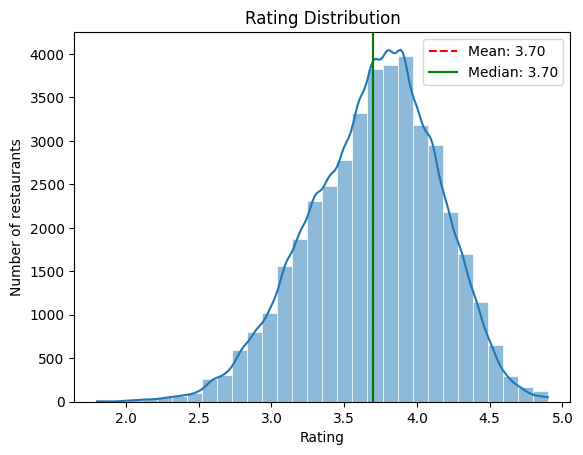

In [22]:
mean_val = d3['rate'].mean()
median_val = d3['rate'].median()
sns.histplot(d3['rate'], bins=30, kde=True,edgecolor='white', linewidth=0.5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of restaurants")
plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color='green', linestyle='-', label=f"Median: {median_val:.2f}")
plt.legend()
plt.show()

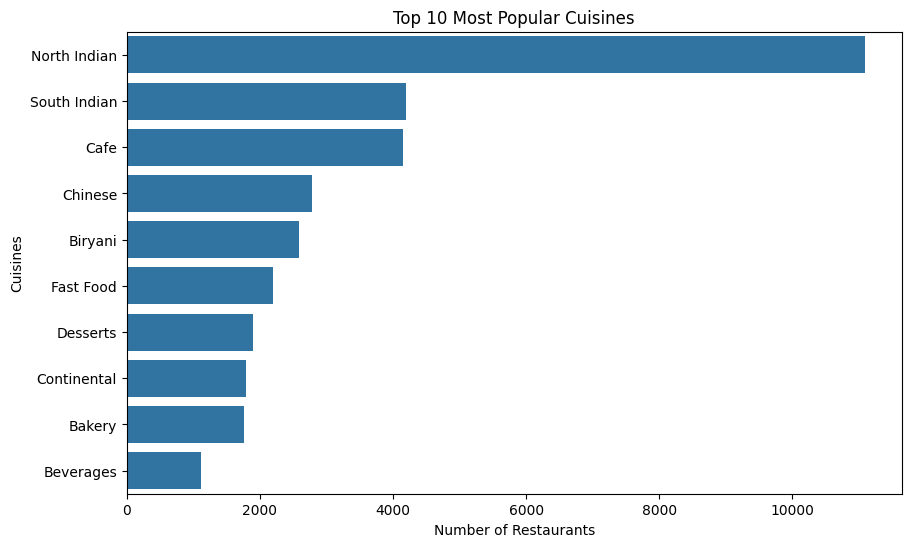

In [23]:
top_cuisines = d3['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisines")
plt.title("Top 10 Most Popular Cuisines")

plt.show()

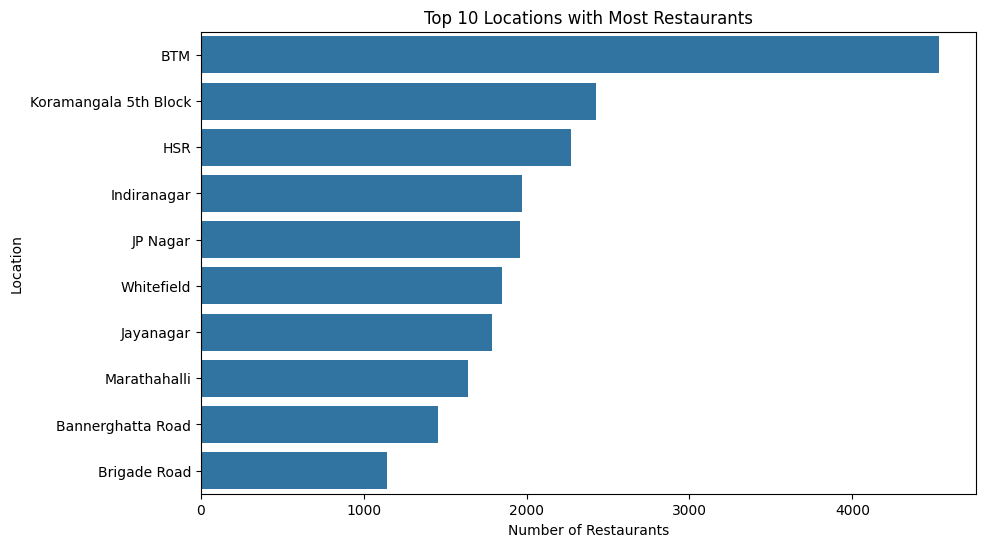

In [24]:
top_locations = d3['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index)

plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.title("Top 10 Locations with Most Restaurants")

plt.show()

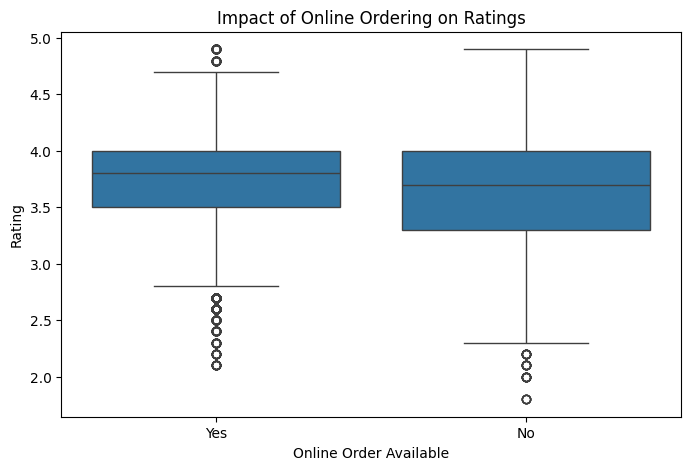

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x='online_order', y='rate', data=d3)

plt.xlabel("Online Order Available")
plt.ylabel("Rating")
plt.title("Impact of Online Ordering on Ratings")

plt.show()

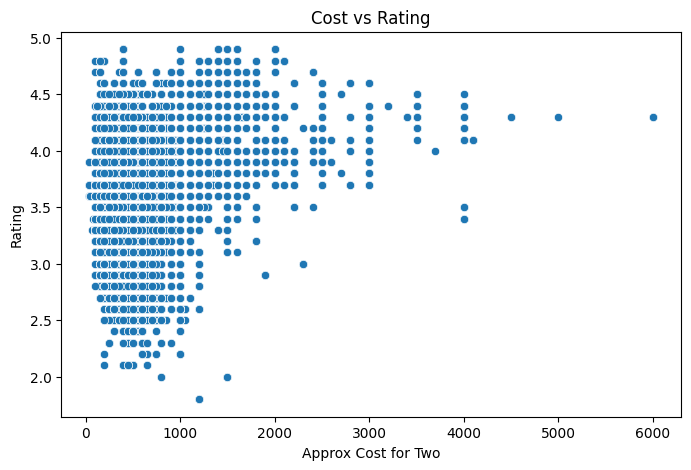

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=d3
    
)

plt.title("Cost vs Rating")
plt.xlabel("Approx Cost for Two")
plt.ylabel("Rating")

plt.show()

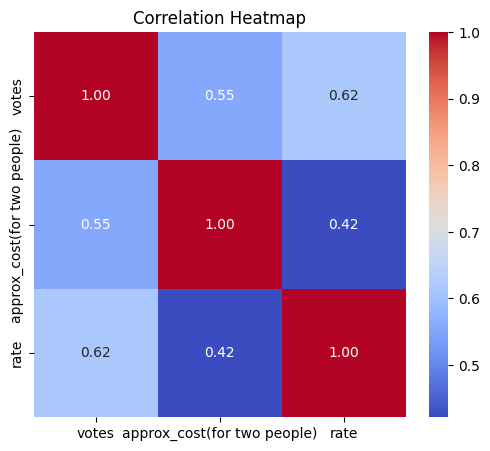

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

corr = d3_clean[['votes', 'approx_cost(for two people)', 'rate']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

d3_model = d3_clean.copy()

le = LabelEncoder()

d3_model['location_enc'] = le.fit_transform(d3_model['location'])
d3_model['cuisines_enc'] = le.fit_transform(d3_model['cuisines'])
d3_model['rest_type_enc'] = le.fit_transform(d3_model['rest_type'])

d3_model['online_order'] = d3_model['online_order'].map({'Yes': 1, 'No': 0})
d3_model['book_table'] = d3_model['book_table'].map({'Yes': 1, 'No': 0})

In [29]:
features = [
    'votes',
    'approx_cost(for two people)',
    'rate',
    'location_enc',
    'cuisines_enc',
    'rest_type_enc',
    'online_order',
    'book_table'
]

X = d3_model[features]

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

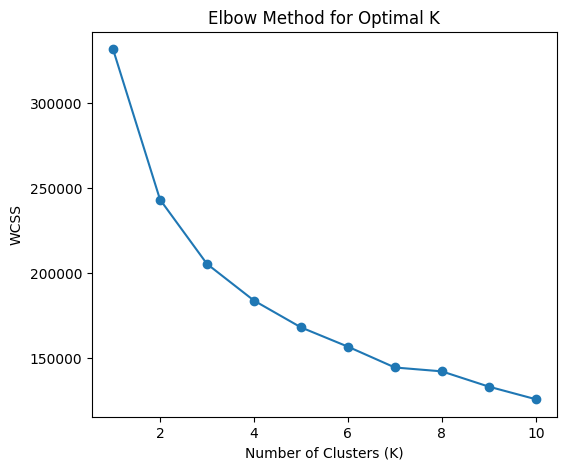

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)   
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=5, random_state=42)
d3_model['cluster'] = kmeans.fit_predict(X_scaled)

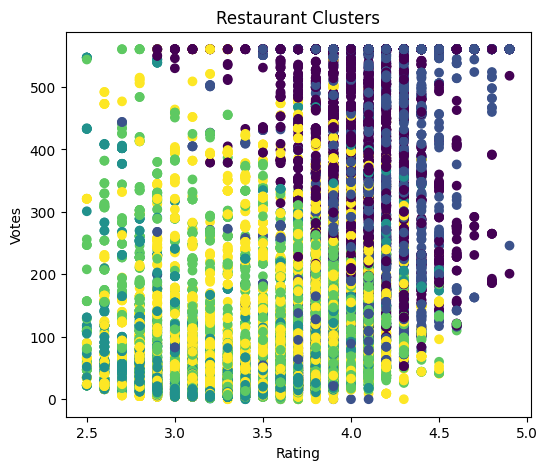

In [33]:
plt.figure(figsize=(6,5))
plt.scatter(d3_model['rate'], d3_model['votes'], c=d3_model['cluster'], cmap='viridis')
plt.xlabel("Rating")
plt.ylabel("Votes")
plt.title("Restaurant Clusters")
plt.show()

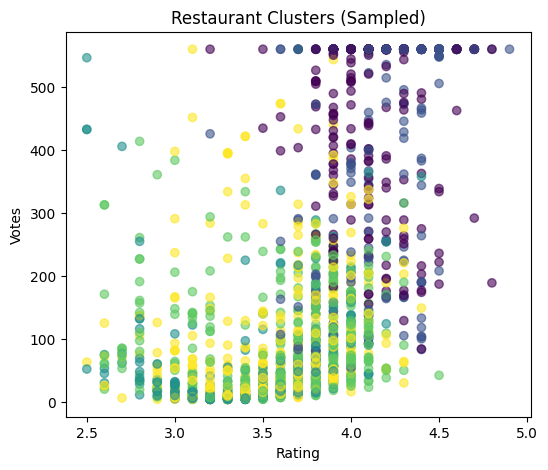

In [34]:
sample_data = d3_model.sample(2000, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(
    sample_data['rate'], 
    sample_data['votes'], 
    c=sample_data['cluster'], 
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("Rating")
plt.ylabel("Votes")
plt.title("Restaurant Clusters (Sampled)")
plt.show()

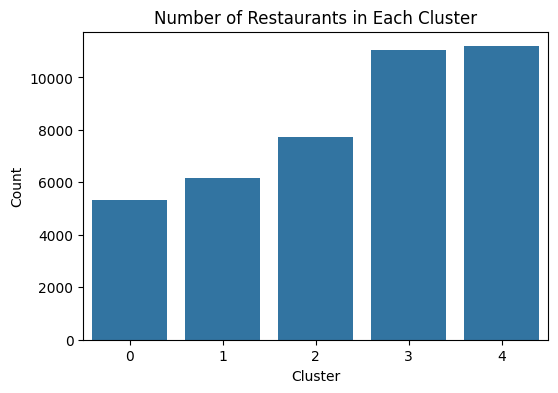

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='cluster', data=d3_model)
plt.title("Number of Restaurants in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [36]:
cluster_summary = d3_model.groupby('cluster')[[
    'rate',
    'votes',
    'approx_cost(for two people)'
]].mean()

print(cluster_summary)

             rate       votes  approx_cost(for two people)
cluster                                                   
0        4.113030  462.532433                   695.494938
1        4.158986  427.435476                  1087.945272
2        3.433372   44.957768                   399.270309
3        3.605462   78.176511                   540.259987
4        3.553120   81.415788                   339.880744


In [37]:
d3_model.groupby('cluster')['cuisines'].agg(lambda x: x.mode()[0])

cluster
0            Cafe
1    North Indian
2    North Indian
3            Cafe
4    North Indian
Name: cuisines, dtype: object

In [42]:
def recommend_restaurants(data, cuisine, location, max_cost):
 
    filtered = data[
        (data['cuisines'].str.contains(cuisine, case=False, na=False)) &
        (data['location'].str.contains(location, case=False, na=False)) &
        (data['approx_cost(for two people)'] <= max_cost)
    ]
    
    if filtered.empty:
        return "No matching restaurants found"
 
    cluster_id = filtered.iloc[0]['cluster']

    recommendations = data[data['cluster'] == cluster_id]

    recommendations = recommendations[
        (recommendations['cuisines'].str.contains(cuisine, case=False, na=False)) &
        (recommendations['location'].str.contains(location, case=False, na=False)) &
        (recommendations['approx_cost(for two people)'] <= max_cost)
    ]
    
    recommendations = recommendations.sort_values(
        by=['rate', 'votes'], ascending=False
    )
    
    recommendations = recommendations.drop_duplicates(subset='name')
    
    recommendations = recommendations.head()
    
    return recommendations[['name', 'location', 'cuisines', 'rate', 'votes', 'approx_cost(for two people)']]

In [44]:
cuisine = input("Enter cuisine: ")
location = input("Enter location: ")
max_cost = int(input("Enter max budget: "))

result = recommend_restaurants(d3_model, cuisine, location, max_cost)

print(result)

Enter cuisine:  North Indian
Enter location:  Vijay Nagar
Enter max budget:  1000


                       name     location      cuisines  rate  votes  \
402              Sip n Dine  Vijay Nagar  North Indian   3.6  218.0   
46266  Hotel New Panchavati  Vijay Nagar  North Indian   3.6  121.0   

       approx_cost(for two people)  
402                          800.0  
46266                        600.0  
